# GPGN470 Homework 5, 04/06/2026
### Lillian Hanson

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [2]:
######### HELPER FUNCTIONS
# Function for histogram equalization. Takes an image in, spits a stretched image out
def histeq(im,n_bins=256):
    
    #get image histogram
    vals,bins = np.histogram(im.flatten(), bins=n_bins, range=(0,n_bins), density=True)
    cdf = np.cumsum(vals)
    im2 = np.interp(im.flatten(),bins[:-1],cdf*255)
    im2[im2>255]=255
    return im2.reshape(im.shape)

# Function for linear contrast stretch. Takes an image in, spits a stretched image out
def histlin(im,n_bins=256):
    
    # find min and max of image
    pixels=im.flatten()
    minval=pixels.min()
    maxval=pixels.max()
    
    im2 = (pixels - minval)/(maxval-minval)*255
    return im2.reshape(im.shape)

## Problem (1)

In [3]:
# Problem (1)
#

# Load all seven bands
f = open('hw5_modis/modis1.dat','r'); b1=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis2.dat','r'); b2=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis3.dat','r'); b3=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis4.dat','r'); b4=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis5.dat','r'); b5=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis6.dat','r'); b6=np.genfromtxt(f); f.close()
f = open('hw5_modis/modis7.dat','r'); b7=np.genfromtxt(f); f.close()

# turn it into an MxNx7 matrix just for compactness
modis=np.stack((b1,b2,b3,b4,b5,b6,b7),axis=2)
z = modis

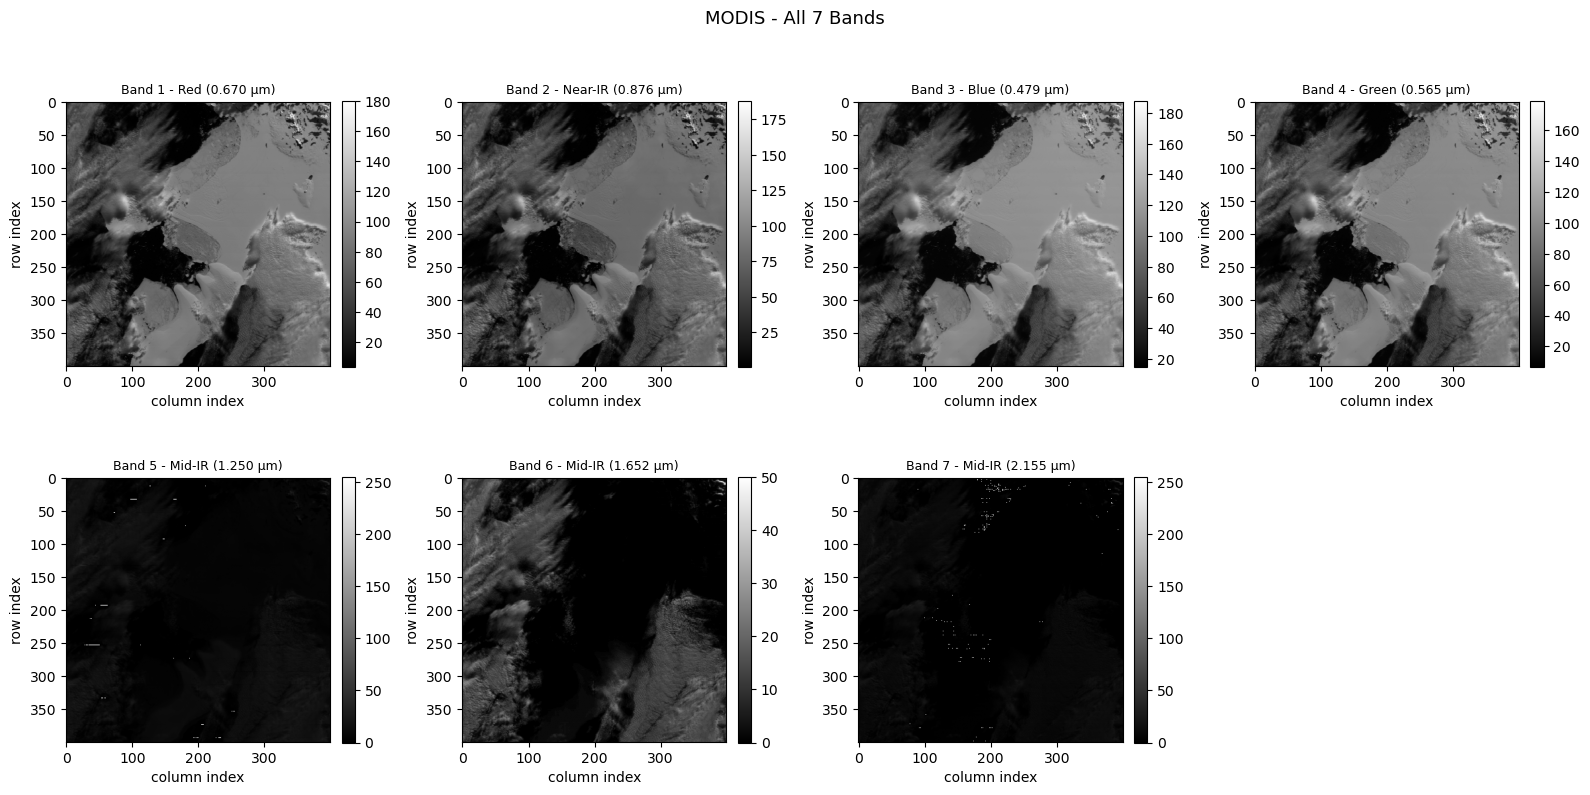

In [4]:
# Problem (1)
# Plot all 7 bands individually in a 2x4 grid (last panel empty)
band_labels = ['Band 1 - Red (0.670 µm)',
               'Band 2 - Near-IR (0.876 µm)',
               'Band 3 - Blue (0.479 µm)',
               'Band 4 - Green (0.565 µm)',
               'Band 5 - Mid-IR (1.250 µm)',
               'Band 6 - Mid-IR (1.652 µm)',
               'Band 7 - Mid-IR (2.155 µm)']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(7):
    im = axes[i].imshow(modis[:, :, i], cmap='gray')
    axes[i].set_title(band_labels[i], fontsize=9)
    axes[i].set_xlabel('column index')
    axes[i].set_ylabel('row index')
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Hide the empty 8th panel
axes[7].set_visible(False)

plt.suptitle('MODIS - All 7 Bands', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

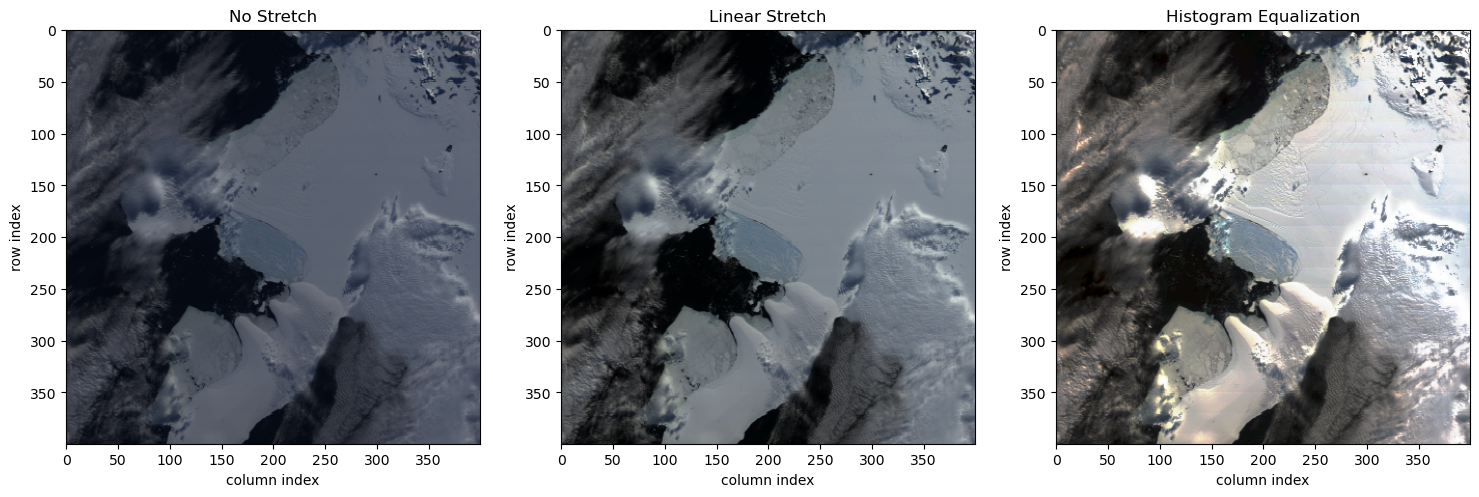

In [5]:
# Problem (1)
# Read in three bands for red, green, and blue
# Pull RGB bands directly from the stacked array (already 2D)
rr = modis[:, :, 0]  # band 1
gg = modis[:, :, 3]  # band 4
bb = modis[:, :, 2]  # band 3

# Apply contrast enhancements to each band
rr_line = histlin(rr);  gg_line = histlin(gg);  bb_line = histlin(bb)
rr_eq   = histeq(rr);   gg_eq   = histeq(gg);   bb_eq   = histeq(bb)

# Stack into MxNx3 RGB images (enhance before stacking, then normalize to 0-1)
rgb      = np.stack((rr,      gg,      bb),      axis=2) / 255.0
rgb_line = np.stack((rr_line, gg_line, bb_line), axis=2) / 255.0
rgb_eq   = np.stack((rr_eq,   gg_eq,   bb_eq),   axis=2) / 255.0

# Plot all three on a single three-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(15)

ax1.imshow(rgb);      ax1.set_title('No Stretch')
ax2.imshow(rgb_line); ax2.set_title('Linear Stretch')
ax3.imshow(rgb_eq);   ax3.set_title('Histogram Equalization')

for ax in (ax1, ax2, ax3):
    ax.set_xlabel('column index')
    ax.set_ylabel('row index')

plt.tight_layout()
plt.show()

### Set up coords

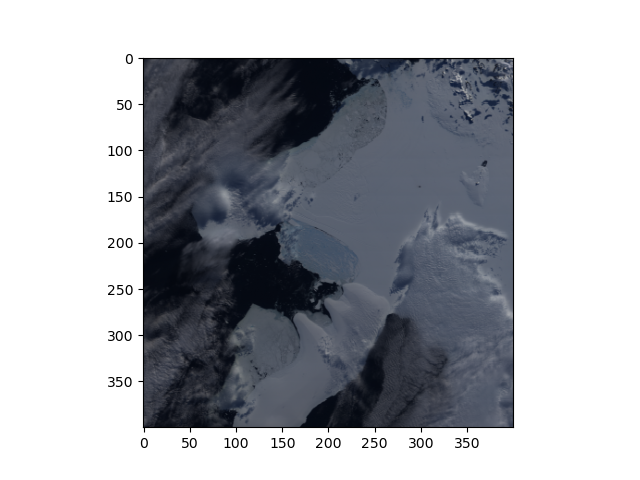

In [6]:
%matplotlib widget

coords=np.array([]) # initialize an empty array for the coordinates to go into

# define what happens when there's a click event
def onclick(event):
    global ix, iy, coords, text
    ix, iy = int(round(event.xdata)), int(round(event.ydata)) # store x,y location
    tx="x = {}, y = {}".format(ix, iy) # string to print on the figure
    
    # if this is your first click, initialize the coords array and the text on figure
    # otherwise, just append the new coordinates and replace the text on the figure
    if coords.shape[0]==0:
        coords=np.array([ix,iy])
        text=ax.text(0,0,tx,va="bottom",ha="left")
    else:
        coords=np.vstack([coords,[ix,iy]])
        text.set_text(tx)
    return coords


# set up a figure that has a listener for clicking the mouse.
fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(modis[:,:,[0,3,2]]/255)
fig.canvas.mpl_connect('button_press_event',onclick)
plt.show()

In [7]:
print(coords)

[]


## Problem (2)

In [8]:
%matplotlib inline
# Problem (2)

tpix = np.array([[292,  96, 1], # group 1, glacier
         [273, 177, 1 ],
         [121, 219, 2], # group 2, ocean
         [146, 242, 2],
         [181, 191, 3], # group 3, blue glacier
         [199, 212, 3],
         [117,  77, 4], # group 4, clouds
         [ 31, 129, 4]])


# Make a list of class names that you'll use for your colorbar labels later

group_names = ['glacier gray',
               'ocean',
               'glacier blue',
               'cloud']
ngroup = 4

In [9]:
# Problem (2)
# From these pixels, make a training set consisting of each training pixel's band values
# "train" should have the same number of rows as the number of training pixels, and the
# same number of columns as number of bands (in this case 7).
#
# Time to classify. We need to massage the training set a bit first...

train = z[tpix[:, 1], tpix[:, 0], :].astype(float)  # shape: (n_training_pixels, 7)
group = tpix[:, 2]                                    # class labels

# Fit LDA classifier on training data
LDA = LinearDiscriminantAnalysis()
LDA.fit_transform(train, group)

array([[-25.68921135,  10.48847894,   0.64093385],
       [-24.38534459,   9.4359761 ,   0.09877501],
       [ 21.81286691,  -0.46581922,   4.54707648],
       [ 24.0898828 ,  -0.63638376,   3.96627399],
       [-20.76170633,  -9.53139545,  -0.42662164],
       [-21.50841152, -12.13921369,  -0.42990555],
       [ 23.59431224,   1.29924906,  -2.84099662],
       [ 22.84761185,   1.54910802,  -5.55553553]])

## Problem (3)

In [10]:
# Problem (3) 
# Reshape full image to (M*N x 7), classify, then reshape back
new_shape = (z.shape[0] * z.shape[1], z.shape[2])
allpix = z[:, :, :].astype(float).reshape(new_shape)  
classified_lda = LDA.predict(allpix).reshape(z[:, :, 0].shape)

## Problem (4)

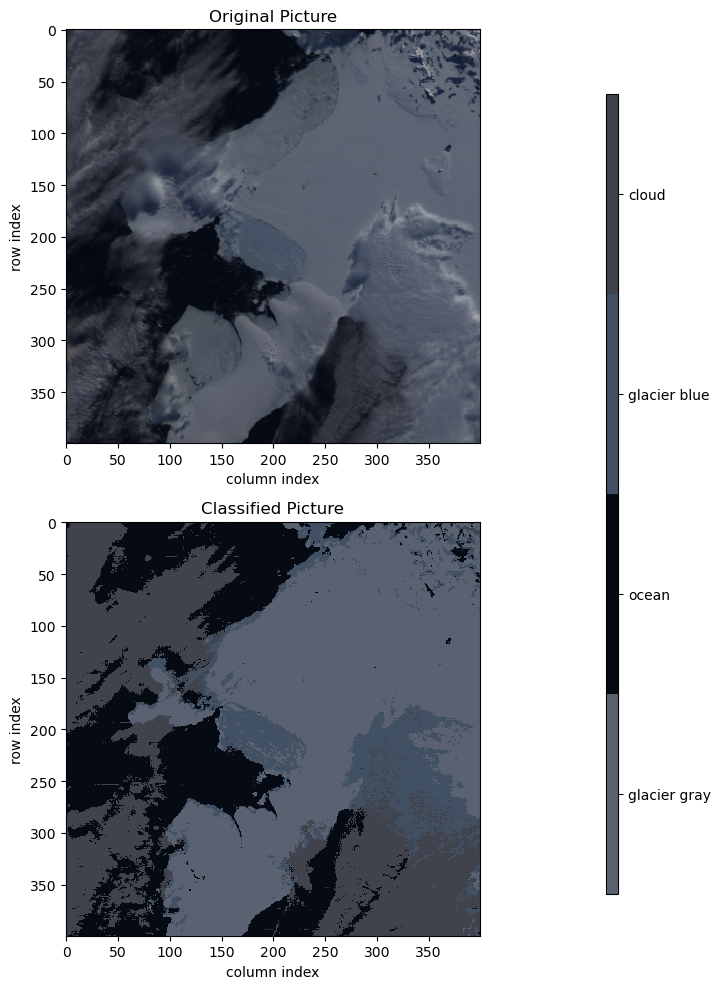

In [14]:
# Problem (4)

# Now lets plot the classified image. 

# Set up a look up table for class => color  (as RGB)
colors = np.array([[90, 98, 113], #glacier
        [5, 10, 19], #ocean
        [65, 80, 98], #blue glacier
        [ 64, 66, 76]]) #cloud

# Python needs 0-1 and not 0-255
colors=colors/255.0

# Make a colormap from the list of colors 
classmap = plt.matplotlib.colors.ListedColormap(colors, 'Classification', ngroup)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.set_figheight(10)

ax1.imshow(rgb)
ax1.set_title('Original Picture')
ax1.set_ylabel('row index')
ax1.set_xlabel('column index')

im = ax2.imshow(classified_lda, cmap=classmap, interpolation='none', vmin=1, vmax=ngroup+1)
ax2.set_title('Classified Picture')
ax2.set_ylabel('row index')
ax2.set_xlabel('column index')

plt.tight_layout()

cax = plt.axes([1.02, 0.1, 0.02, 0.8])
cbar = plt.colorbar(im, cax=cax)
cbar.set_ticks(np.linspace(1.5, ngroup + 0.5, ngroup))  # center ticks within each band
cbar.set_ticklabels(group_names)

plt.show()

My results make sense. The ocean was well-classified, and the clouds are fairly accurate as well. I discuss the clouds more in Bonus #1. I decided to separate the glacier into two colors, which seemed to help with capturing more features.

## Bonus #1

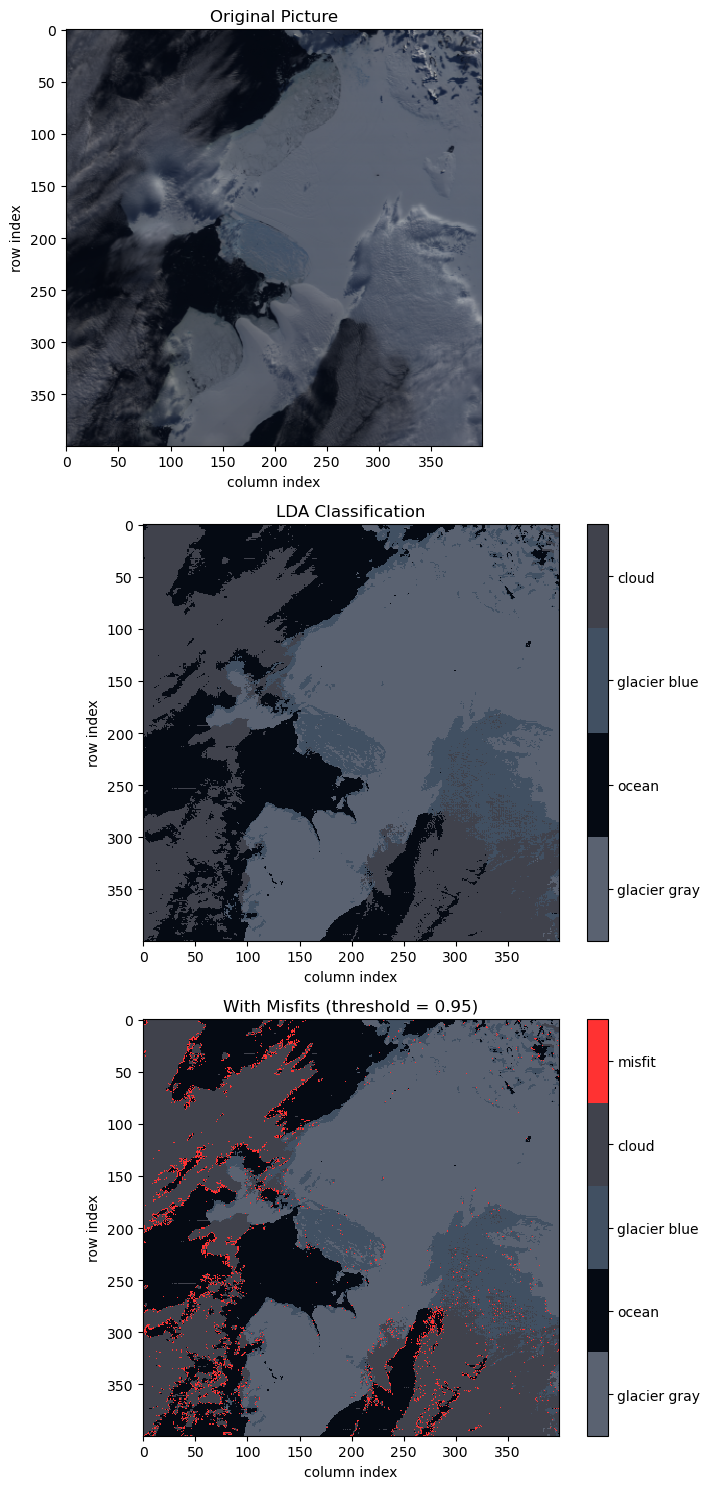

Misfit pixels: 2.7% of image


In [12]:
# Bonus #1: Misfit analysis

# Get probability of belonging to each class for every pixel
probs = LDA.predict_proba(allpix)  # shape: (M*N, ngroup)

# Max probability for each pixel — high = good fit, low = poor fit
max_prob = probs.max(axis=1).reshape(z[:, :, 0].shape)

# Set a threshold
threshold = 0.95  

# Start with the regular classification
classified_misfit = classified_lda.copy()

# Overwrite poorly-fit pixels with a new group label 
classified_misfit[max_prob < threshold] = ngroup + 1

# Build a new colormap with an extra color for misfits (bright red)
colors_misfit = np.array([[90,  98, 113],   # glacier gray
                          [ 5,  10,  19],   # ocean
                          [65,  80,  98],   # blue glacier
                          [64,  66,  76],   # cloud
                          [255,  50,  50]]) / 255.0  # misfit = red

classmap_misfit = plt.matplotlib.colors.ListedColormap(colors_misfit, 'Misfit', ngroup + 1)
group_names_misfit = group_names + ['misfit']

# Plot original, classified, and misfit classification
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 15))

ax1.imshow(rgb)
ax1.set_title('Original Picture')
ax1.set_ylabel('row index')
ax1.set_xlabel('column index')

im2 = ax2.imshow(classified_lda, cmap=classmap, interpolation='none', vmin=1, vmax=ngroup + 1)
ax2.set_title('LDA Classification')
ax2.set_ylabel('row index')
ax2.set_xlabel('column index')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_ticks(np.linspace(1.5, ngroup + 0.5, ngroup))
cbar2.set_ticklabels(group_names)

im3 = ax3.imshow(classified_misfit, cmap=classmap_misfit, interpolation='none', vmin=1, vmax=ngroup + 2)
ax3.set_title(f'With Misfits (threshold = {threshold})')
ax3.set_ylabel('row index')
ax3.set_xlabel('column index')
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_ticks(np.linspace(1.5, ngroup + 1.5, ngroup + 1))
cbar3.set_ticklabels(group_names_misfit)

plt.tight_layout()
plt.show()

# Print what fraction of pixels were flagged as misfits
misfit_frac = (max_prob < threshold).sum() / max_prob.size
print(f"Misfit pixels: {misfit_frac*100:.1f}% of image")

### Bonus (#1):
Most of the misfit pixels in this image are on the boundaries between classifications, especially boundaries between clouds and other classes. Even with a high misfit threshold of 0.95, most of the error remains on these transition areas. This is logical, because clouds tend to not have clean-cut edges.